<a href="https://colab.research.google.com/github/Shreya05118/Fault-Management-/blob/main/fault_management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
DATASET_PATH = "LOSAng.csv"

OUTPUT_FOLDER = "fault_management_results"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

In [ ]:
print("\n" + "=" * 65)
print("FAULT MANAGEMENT USING MACHINE LEARNING")
print("=" * 65)

print("\nLoading dataset...")

df = pd.read_csv(DATASET_PATH)

print("\nDataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# Check required column
if "LOSAng" not in df.columns:
    raise ValueError(
        "LOSAng column was not found in the dataset."
    )



FAULT MANAGEMENT USING MACHINE LEARNING

Loading dataset...

Dataset shape: (3000, 1)

Columns:
['LOSAng']


In [ ]:
print("\nCleaning dataset...")

df["LOSAng"] = pd.to_numeric(df["LOSAng"], errors="coerce")

missing_values = df["LOSAng"].isnull().sum()

print("Missing values:", missing_values)

df = df.dropna(subset=["LOSAng"]).reset_index(drop=True)

# Remove infinite values
df = df[np.isfinite(df["LOSAng"])].reset_index(drop=True)

print("Records after cleaning:", len(df))


Cleaning dataset...
Missing values: 0
Records after cleaning: 3000


In [ ]:
print("\n" + "=" * 65)
print("STATISTICAL SUMMARY")
print("=" * 65)

print(df["LOSAng"].describe())


STATISTICAL SUMMARY
count    3000.000000
mean      417.109507
std        94.104931
min       209.861248
25%       357.842164
50%       415.558772
75%       465.170391
max      1768.461059
Name: LOSAng, dtype: float64


In [ ]:
df["Sample"] = np.arange(1, len(df) + 1)


In [ ]:
print("\nCreating ML features...")

# Rolling statistics
df["Rolling_Mean"] = (
    df["LOSAng"]
    .rolling(window=20, min_periods=1)
    .mean()
)

df["Rolling_Std"] = (
    df["LOSAng"]
    .rolling(window=20, min_periods=1)
    .std()
)

df["Rolling_Min"] = (
    df["LOSAng"]
    .rolling(window=20, min_periods=1)
    .min()
)

df["Rolling_Max"] = (
    df["LOSAng"]
    .rolling(window=20, min_periods=1)
    .max()
)

# Difference between consecutive measurements
df["Change"] = df["LOSAng"].diff().fillna(0)

# Absolute change
df["Abs_Change"] = df["Change"].abs()

# Z-score-like rolling deviation
rolling_mean = (
    df["LOSAng"]
    .rolling(window=20, min_periods=1)
    .mean()
)

rolling_std = (
    df["LOSAng"]
    .rolling(window=20, min_periods=1)
    .std()
)

rolling_std = rolling_std.replace(0, np.nan)

df["Deviation"] = (
    (df["LOSAng"] - rolling_mean) /
    rolling_std
)

df["Deviation"] = df["Deviation"].replace(
    [np.inf, -np.inf], 0
).fillna(0)


Creating ML features...


In [ ]:
features = [
    "LOSAng",
    "Rolling_Mean",
    "Rolling_Std",
    "Change",
    "Abs_Change",
    "Deviation"
]

X = df[features].copy()

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(0)


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
print("\nTraining Isolation Forest...")

model = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42,
    max_samples="auto",
    max_features=1.0,
    bootstrap=False
)

model.fit(X_scaled)


Training Isolation Forest...


IsolationForest(contamination=0.05, n_estimators=300, random_state=42)

In [ ]:
df["Prediction"] = model.predict(X_scaled)

df["Anomaly_Score"] = model.decision_function(X_scaled)

# Isolation Forest:
#  1  = normal
# -1  = anomaly

df["Fault"] = np.where(
    df["Prediction"] == -1,
    "Fault",
    "Normal"
)


In [ ]:
normal_count = (
    df["Fault"] == "Normal"
).sum()

fault_count = (
    df["Fault"] == "Fault"
).sum()

total_count = len(df)

fault_percentage = (
    fault_count / total_count
) * 100

normal_percentage = (
    normal_count / total_count
) * 100


print("\n" + "=" * 65)
print("FAULT DETECTION RESULTS")
print("=" * 65)

print(f"\nTotal samples      : {total_count}")
print(f"Normal samples     : {normal_count}")
print(f"Fault samples      : {fault_count}")
print(f"Normal percentage  : {normal_percentage:.2f}%")
print(f"Fault percentage   : {fault_percentage:.2f}%")


FAULT DETECTION RESULTS

Total samples      : 3000
Normal samples     : 2850
Fault samples      : 150
Normal percentage  : 95.00%
Fault percentage   : 5.00%


In [ ]:
try:

    labels = df["Prediction"]

    if len(np.unique(labels)) == 2:

        score = silhouette_score(
            X_scaled,
            labels
        )

        print(
            f"\nSilhouette Score   : {score:.4f}"
        )

    else:

        score = None

except Exception:

    score = None


Silhouette Score   : 0.6268


In [ ]:
output_csv = os.path.join(
    OUTPUT_FOLDER,
    "fault_detection_results.csv"
)

df.to_csv(
    output_csv,
    index=False
)

print(
    f"\nResult dataset saved to:\n{output_csv}"
)



Result dataset saved to:
fault_management_results/fault_detection_results.csv


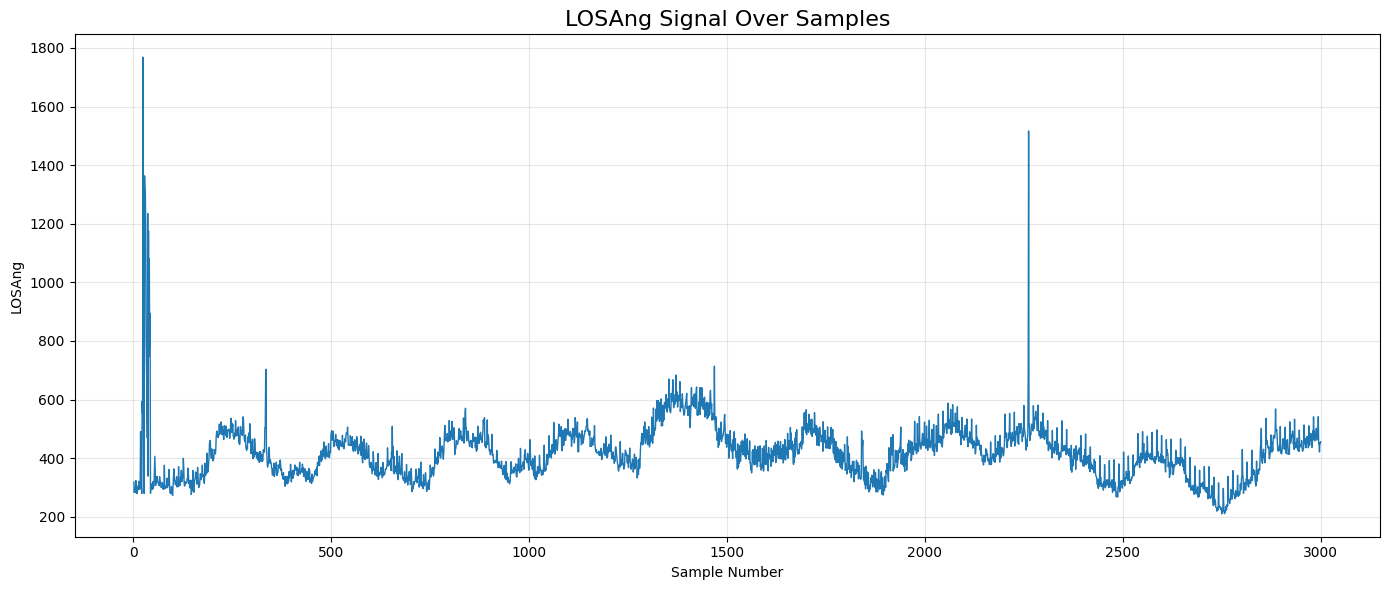

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Sample"],
    df["LOSAng"],
    linewidth=1
)

plt.title(
    "LOSAng Signal Over Samples",
    fontsize=16
)

plt.xlabel("Sample Number")
plt.ylabel("LOSAng")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "01_original_signal.png"
    ),
    dpi=300
)

plt.show()


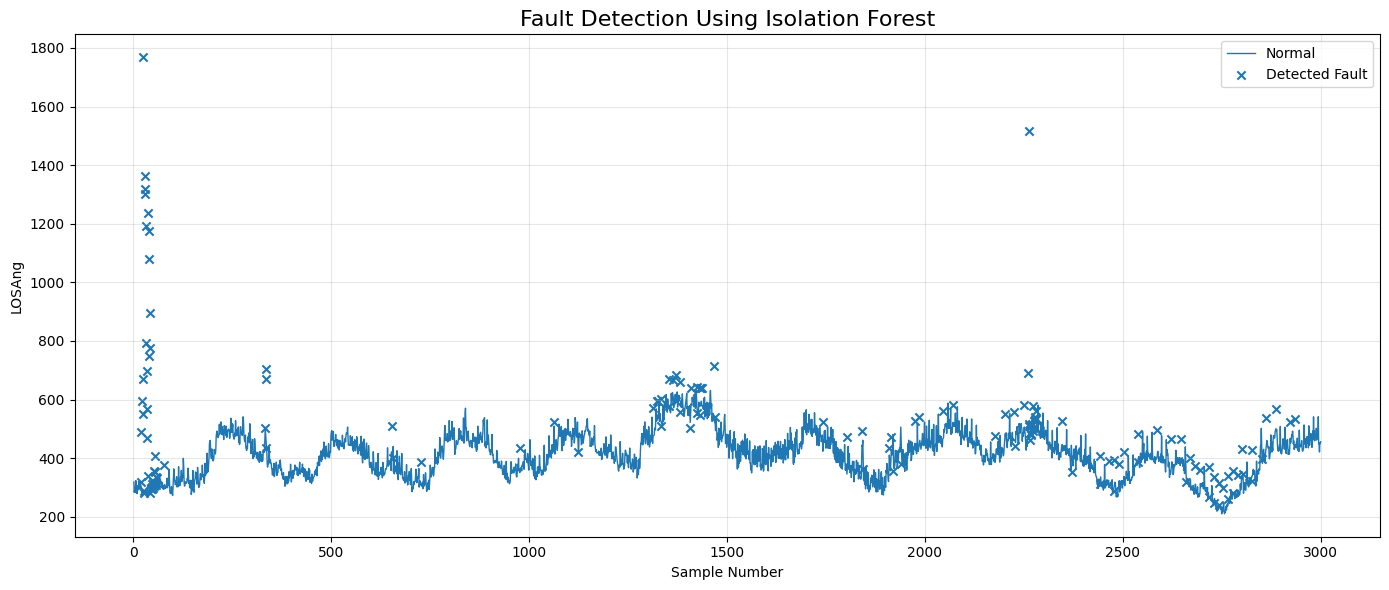

In [ ]:
plt.figure(figsize=(14, 6))

normal_data = df[
    df["Fault"] == "Normal"
]

fault_data = df[
    df["Fault"] == "Fault"
]

plt.plot(
    normal_data["Sample"],
    normal_data["LOSAng"],
    label="Normal",
    linewidth=1
)

plt.scatter(
    fault_data["Sample"],
    fault_data["LOSAng"],
    label="Detected Fault",
    s=35,
    marker="x"
)

plt.title(
    "Fault Detection Using Isolation Forest",
    fontsize=16
)

plt.xlabel("Sample Number")
plt.ylabel("LOSAng")

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "02_fault_detection.png"
    ),
    dpi=300
)

plt.show()

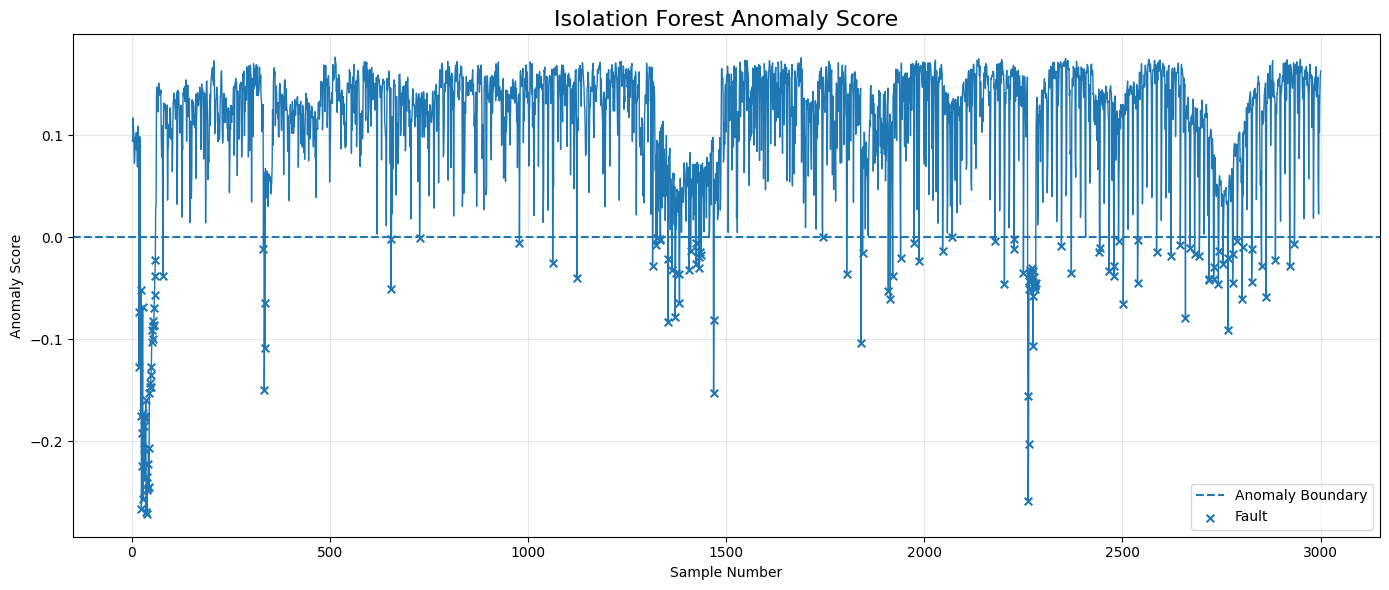

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Sample"],
    df["Anomaly_Score"],
    linewidth=1
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5,
    label="Anomaly Boundary"
)

plt.scatter(
    fault_data["Sample"],
    fault_data["Anomaly_Score"],
    s=30,
    marker="x",
    label="Fault"
)

plt.title(
    "Isolation Forest Anomaly Score",
    fontsize=16
)

plt.xlabel("Sample Number")
plt.ylabel("Anomaly Score")

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "03_anomaly_score.png"
    ),
    dpi=300
)

plt.show()

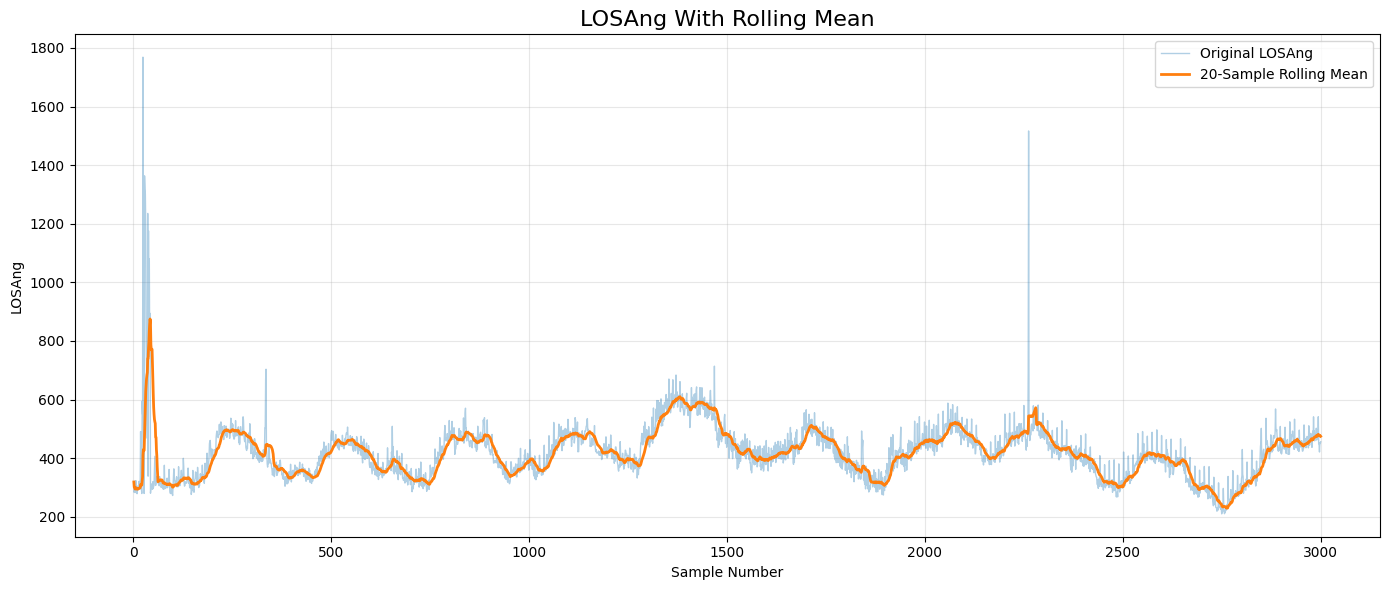

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Sample"],
    df["LOSAng"],
    alpha=0.35,
    linewidth=1,
    label="Original LOSAng"
)

plt.plot(
    df["Sample"],
    df["Rolling_Mean"],
    linewidth=2,
    label="20-Sample Rolling Mean"
)

plt.title(
    "LOSAng With Rolling Mean",
    fontsize=16
)

plt.xlabel("Sample Number")
plt.ylabel("LOSAng")

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "04_rolling_mean.png"
    ),
    dpi=300
)

plt.show()

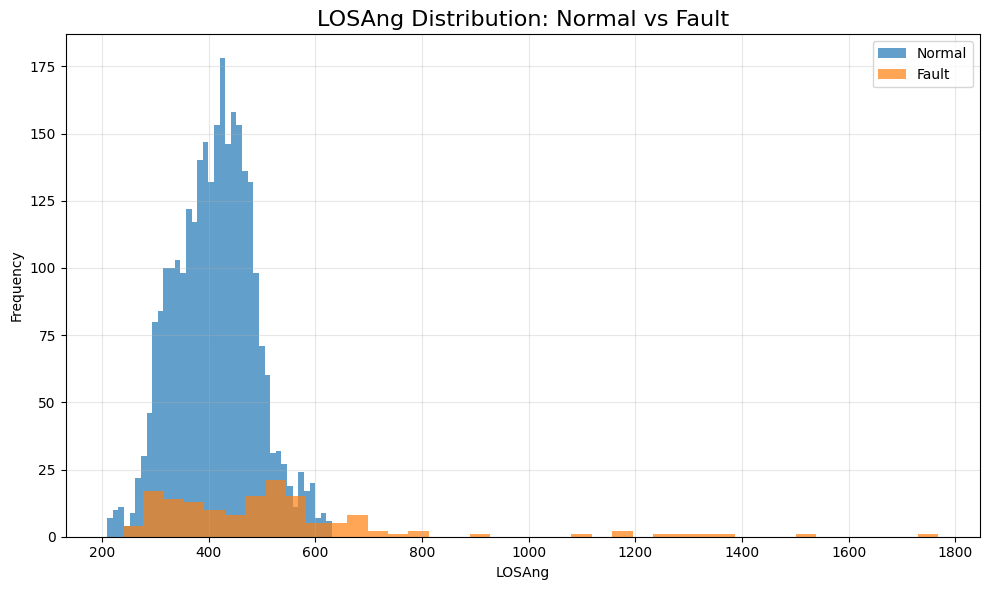

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    normal_data["LOSAng"],
    bins=40,
    alpha=0.7,
    label="Normal"
)

plt.hist(
    fault_data["LOSAng"],
    bins=40,
    alpha=0.7,
    label="Fault"
)

plt.title(
    "LOSAng Distribution: Normal vs Fault",
    fontsize=16
)

plt.xlabel("LOSAng")
plt.ylabel("Frequency")

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "05_distribution.png"
    ),
    dpi=300
)

plt.show()


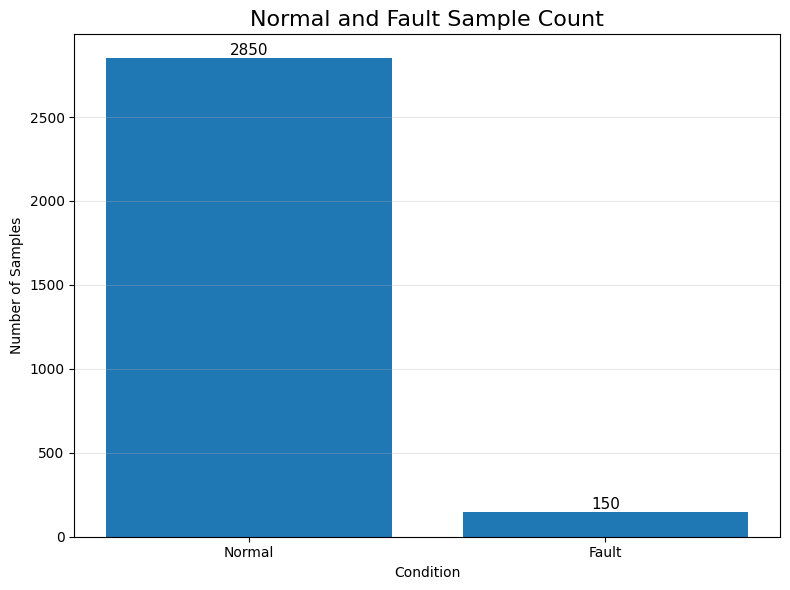

In [ ]:
plt.figure(figsize=(8, 6))

categories = [
    "Normal",
    "Fault"
]

counts = [
    normal_count,
    fault_count
]

bars = plt.bar(
    categories,
    counts
)

plt.title(
    "Normal and Fault Sample Count",
    fontsize=16
)

plt.xlabel("Condition")
plt.ylabel("Number of Samples")

# Add values above bars
for bar, value in zip(bars, counts):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(value),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "06_normal_fault_count.png"
    ),
    dpi=300
)

plt.show()


In [ ]:
top_faults = (
    df[df["Fault"] == "Fault"]
    .sort_values(
        "Anomaly_Score"
    )
    .head(20)
)

print("\n" + "=" * 65)
print("TOP 20 MOST SEVERE DETECTED FAULTS")
print("=" * 65)

print(
    top_faults[
        [
            "Sample",
            "LOSAng",
            "Anomaly_Score",
            "Deviation"
        ]
    ].to_string(index=False)
)



TOP 20 MOST SEVERE DETECTED FAULTS
 Sample      LOSAng  Anomaly_Score  Deviation
     38 1175.844542      -0.271311   0.869703
     36 1235.166949      -0.269492   1.086512
     24 1768.461059      -0.266680   4.083931
   2262 1516.582438      -0.258365   4.122920
     28 1363.408246      -0.256455   2.237128
     37  338.630298      -0.248137  -0.882252
     40 1081.076671      -0.246332   0.562500
     43  280.462116      -0.244620  -1.357225
     32  793.089261      -0.236036   0.299586
     39  747.920221      -0.234776  -0.107180
     25  668.678630      -0.224615   0.712731
     41  776.658595      -0.222711  -0.199647
     31 1191.381724      -0.207379   1.185505
     42  894.299917      -0.206703   0.046643
   2263  508.721313      -0.202334  -0.147658
     26  286.464559      -0.192050  -0.417777
     30 1301.585081      -0.185480   1.557042
     33  696.960786      -0.177298   0.054397
     22  594.119590      -0.175479   3.471431
     34  567.144063      -0.174930  -0.25598

In [ ]:
top_faults.to_csv(
    os.path.join(
        OUTPUT_FOLDER,
        "top_20_faults.csv"
    ),
    index=False
)

In [ ]:
report_path = os.path.join(
    OUTPUT_FOLDER,
    "model_report.txt"
)

with open(
    report_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        "FAULT MANAGEMENT USING MACHINE LEARNING\n"
    )

    file.write("=" * 60 + "\n\n")

    file.write(
        f"Dataset size: {total_count}\n"
    )

    file.write(
        f"Normal samples: {normal_count}\n"
    )

    file.write(
        f"Fault samples: {fault_count}\n"
    )

    file.write(
        f"Normal percentage: {normal_percentage:.2f}%\n"
    )

    file.write(
        f"Fault percentage: {fault_percentage:.2f}%\n"
    )

    if score is not None:

        file.write(
            f"Silhouette score: {score:.4f}\n"
        )

    file.write(
        "\nAlgorithm: Isolation Forest\n"
    )

    file.write(
        "Number of estimators: 300\n"
    )

    file.write(
        "Contamination: 5%\n"
    )


print("\n" + "=" * 65)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 65)

print(
    f"\nAll results are available in:\n"
    f"{OUTPUT_FOLDER}/"
)

print("\nGenerated files:")

print("1. fault_detection_results.csv")
print("2. top_20_faults.csv")
print("3. model_report.txt")
print("4. 01_original_signal.png")
print("5. 02_fault_detection.png")
print("6. 03_anomaly_score.png")
print("7. 04_rolling_mean.png")
print("8. 05_distribution.png")
print("9. 06_normal_fault_count.png")

print("\nDone.")


PROJECT COMPLETED SUCCESSFULLY

All results are available in:
fault_management_results/

Generated files:
1. fault_detection_results.csv
2. top_20_faults.csv
3. model_report.txt
4. 01_original_signal.png
5. 02_fault_detection.png
6. 03_anomaly_score.png
7. 04_rolling_mean.png
8. 05_distribution.png
9. 06_normal_fault_count.png

Done.
